In [19]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [20]:
data=pd.read_csv("CarPrice_Assignment.csv")
data

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,201,-1,volvo 145e (sw),gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0
201,202,-1,volvo 144ea,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0
202,203,-1,volvo 244dl,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0
203,204,-1,volvo 246,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470.0


In [21]:
df=pd.DataFrame(data)

In [22]:
x1=df["enginesize"]
x2=df["horsepower"]
y=df["price"]
X=np.column_stack((x1,x2))
Y=np.array(y)

In [23]:
model = LinearRegression()
model.fit(X,Y)

LinearRegression()

In [24]:
Y_pred=model.predict(X)

In [25]:
r2=r2_score(Y,Y_pred)

In [26]:
print("Slope for Engine Size:",model.coef_[0])
print("Slope for Horse Power:",model.coef_[1])
print("Intercept:",model.intercept_)
print("R2 Score:",r2)

Slope for Engine Size: 122.44701649301356
Slope for Horse Power: 58.84742172167146
Intercept: -8389.733089315105
R2 Score: 0.7933407860777293


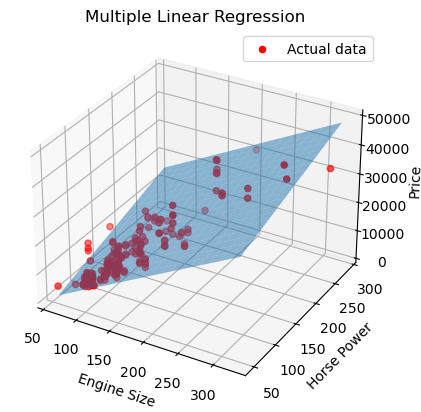

In [28]:
x1_range=np.linspace(min(x1), max(x1), 20)
x2_range=np.linspace(min(x2), max(x2), 20)
x1_grid, x2_grid=np.meshgrid(x1_range, x2_range)
y_grid=model.predict(np.column_stack((x1_grid.ravel(), x2_grid.ravel()))).reshape(x1_grid.shape)
fig=plt.figure()
ax=fig.add_subplot(111, projection='3d')
ax.scatter(x1, x2, Y, color="red", label="Actual data")
ax.plot_surface(x1_grid, x2_grid, y_grid, alpha=0.5)
ax.set_xlabel("Engine Size")
ax.set_ylabel("Horse Power")
ax.set_zlabel("Price")
ax.set_title("Multiple Linear Regression")
plt.legend()
plt.show()

In [29]:
prediction=model.predict([[147,113]])
print(prediction[0])

16259.736989706762
